# Test separation U-Net on mel dataset

This notebook loads a trained checkpoint, runs inference on test samples, and visualizes predicted vs target mel spectrograms.

In [1]:
from pathlib import Path
import sys
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

PROJECT_DIR = Path.cwd()
if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))

from dataset.mel_dataset import MelDataset, MelDatasetConfig, collate_mel_dataset
from model.separation_unet import SeparationUNet, SeparationUNetConfig


In [2]:
MEL_ROOT = Path('../musdb18/mels')
CHECKPOINT_PATH = Path('../train/checkpoints/best.pt')
TARGET_STEMS = ('drums', 'bass', 'other', 'vocals')
BATCH_SIZE = 1
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

test_ds = MelDataset(MelDatasetConfig(root_dir=MEL_ROOT, split='test', target_stems=TARGET_STEMS, return_metadata=True))
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_mel_dataset)

checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
model = SeparationUNet(SeparationUNetConfig(out_stems=len(TARGET_STEMS), stem_names=TARGET_STEMS)).to(DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print('loaded epoch:', checkpoint.get('epoch'))
print('stored test loss:', checkpoint.get('test_loss'))

loaded epoch: 13
stored test loss: 0.13695272803231168


In [3]:
criterion = torch.nn.L1Loss()
total_loss = 0.0

with torch.no_grad():
    for batch in test_loader:
        mixture = batch.mixture.to(DEVICE)
        target = batch.target.to(DEVICE)
        pred = model(mixture)
        loss = criterion(pred, target)
        total_loss += loss.item() * mixture.size(0)

print('mean test L1:', total_loss / len(test_ds))


mean test L1: 0.13695270337634777


In [5]:
batch = next(iter(test_loader))
mixture = batch.mixture.to(DEVICE)
target = batch.target.to(DEVICE)

with torch.no_grad():
    pred = model(mixture).cpu()

mixture = mixture.cpu()
target = target.cpu()

# print('song:', batch.song_names[0])
# print('chunk:', batch.chunk_names[0])
# print('mixture shape:', tuple(mixture.shape))
print('target shape:', tuple(target.shape))
print('pred shape:', tuple(pred.shape))

target shape: (1, 4, 128, 862)
pred shape: (1, 4, 128, 862)


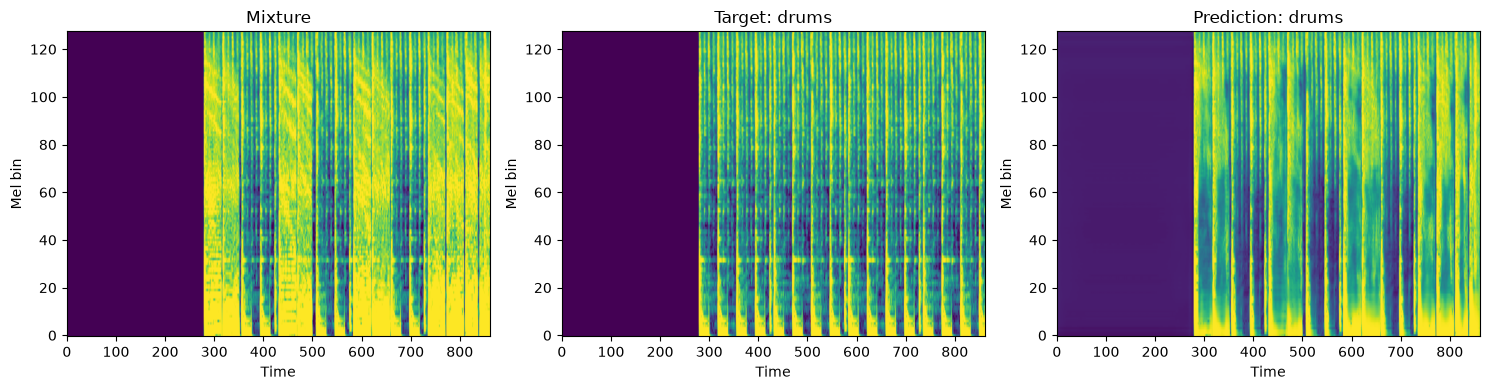

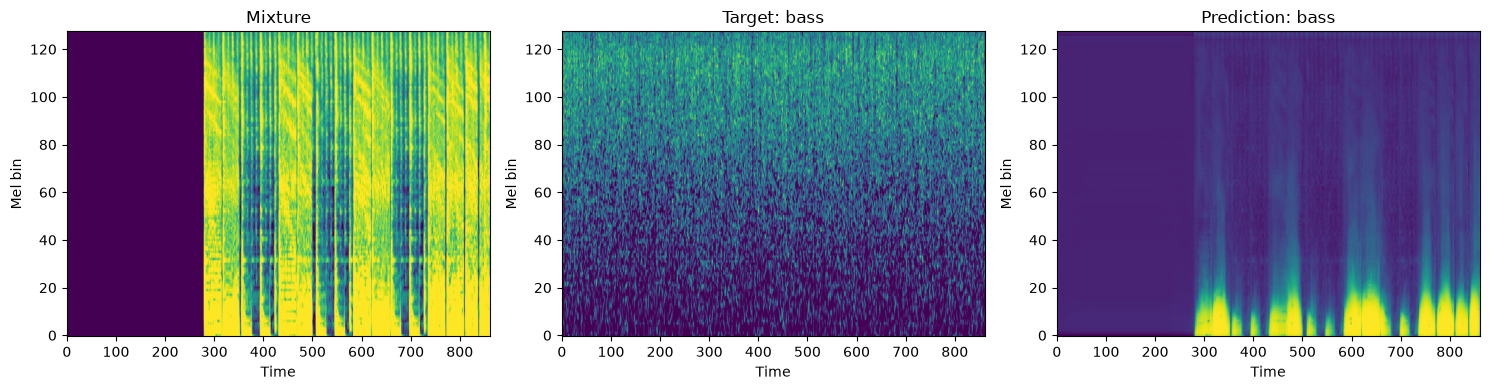

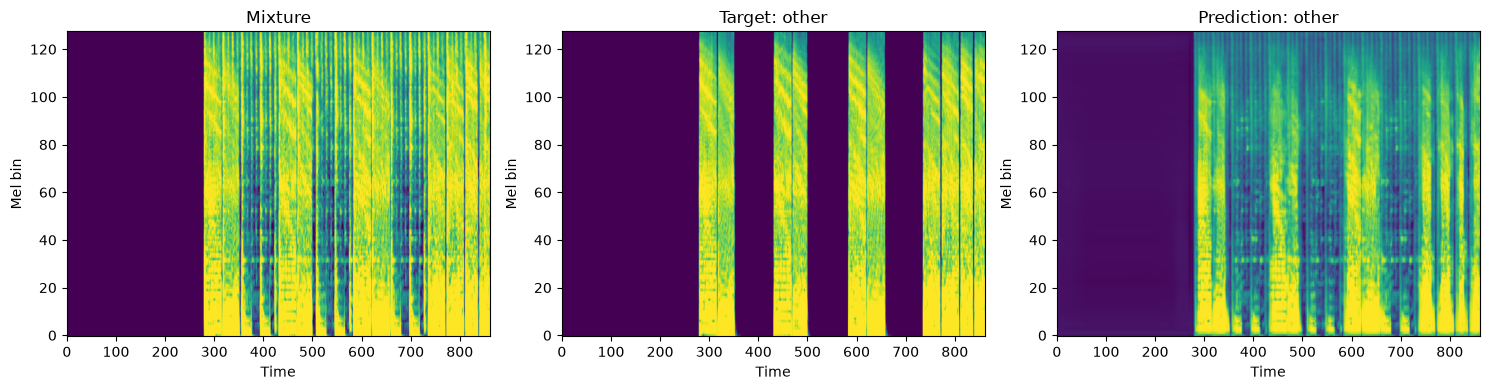

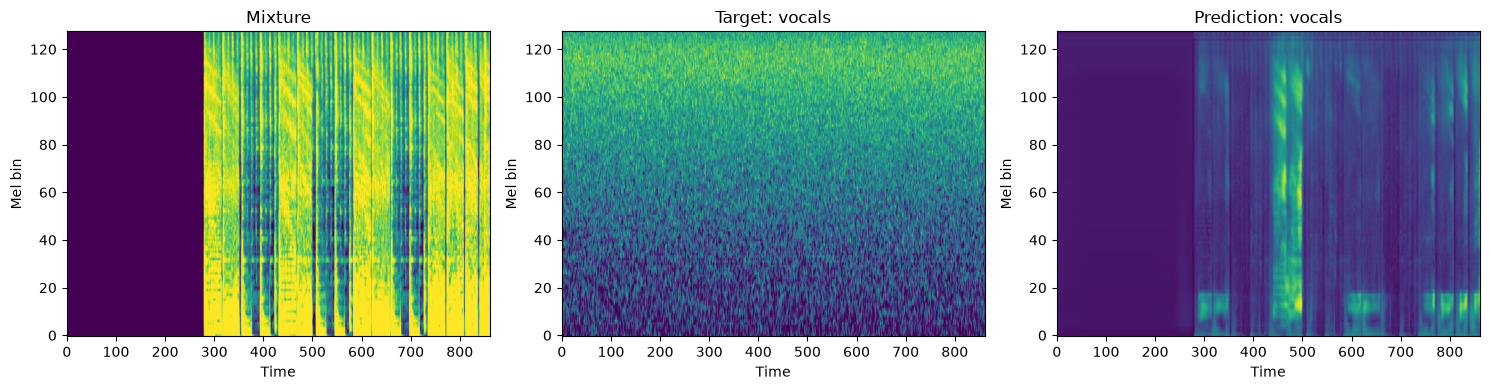

In [9]:
sample_idx = 0

for stem_idx in range(len(TARGET_STEMS)):
    stem_name = TARGET_STEMS[stem_idx]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].imshow(mixture[sample_idx, 0], origin='lower', aspect='auto')
    axes[0].set_title('Mixture')
    axes[1].imshow(target[sample_idx, stem_idx], origin='lower', aspect='auto')
    axes[1].set_title(f'Target: {stem_name}')
    axes[2].imshow(pred[sample_idx, stem_idx], origin='lower', aspect='auto')
    axes[2].set_title(f'Prediction: {stem_name}')
    for ax in axes:
        ax.set_xlabel('Time')
        ax.set_ylabel('Mel bin')
    plt.tight_layout()
    plt.show()